# Climate Projections Database Chatbot

## Setup

In [1]:
import sqlite3
import pandas as pd
import requests
import os
import re
import matplotlib.pyplot as plt
from getpass import getpass

In [2]:
OPENAI_API_KEY = getpass("Enter your OpenAI API key: ").strip()

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

assert os.getenv("OPENAI_API_KEY") and " " not in os.getenv("OPENAI_API_KEY")

Enter your OpenAI API key:  ········


## Verify

In [ ]:
# Connect to database
conn = sqlite3.connect("../data/climate_projections_database.sqlite", check_same_thread=False)

In [4]:
# Quick check - list tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables

,name
0,grid_cell_historic_rainfall
1,grid_asset_link_table
2,grid_cell_values_historic_rainfall
3,climate_projection_grid_ref
4,climate_projection_measurements_updated


In [5]:
pd.read_sql("""
SELECT measurement_date, precipitation
FROM grid_cell_values_historic_rainfall
WHERE measurement_date BETWEEN '2022-12-01' AND '2022-12-31'
LIMIT 5;
""", conn)

,measurement_date,precipitation
0,2022-12-01,3.274
1,2022-12-02,1.330
2,2022-12-03,3.608
3,2022-12-04,1.098
4,2022-12-05,1.203


## Agentic Code

### Setup

In [6]:
%pip install openai-agents

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\romancollinge\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [7]:
import os
from agents import Agent, ModelSettings, function_tool, Runner, SQLiteSession

### Logic

In [8]:
@function_tool  # exposes to the agent with a proper function schema
def get_schema() -> str:
    """Return a concise SQLite schema (tables + columns with types) for the connected database."""
    cur = conn.cursor()
    tables = [r[0] for r in cur.execute("SELECT name FROM sqlite_master WHERE type='table'")]
    lines = []
    for t in tables:
        cols = cur.execute(f"PRAGMA table_info({t})").fetchall()
        # PRAGMA columns: cid, name, type, notnull, dflt_value, pk
        colspec = ", ".join([f"{c[1]} {c[2]}" for c in cols])
        lines.append(f"{t}({colspec})")
    return "\n".join(lines)

@function_tool
def execute_sql(sql: str) -> str:
    """
    Execute a **read-only** SELECT against the SQLite DB and return a small table (CSV).
    Only SELECT queries are allowed; LIMIT is applied server-side for safety.
    """
    s = sql.strip().rstrip(";")
    if not s.lower().startswith("select"):
        return "ERROR: Only SELECT statements are allowed."
    banned = ["insert", "update", "delete", "drop", "alter", "attach", "pragma", "create", "replace"]
    # Use regex word boundaries to avoid catching harmless substrings
    if any(re.search(rf"\b{tok}\b", s, re.IGNORECASE) for tok in banned):
        return "ERROR: Query rejected (non-read-only)."

    try:
        df = pd.read_sql_query(s, conn)
        return df.to_csv(index=False)
    except Exception as e:
        return f"ERROR executing SQL: {e}"

In [9]:
system_prompt = """
You are a data analyst assistant working with a SQLite database.

Your job:
1. Always call get_schema() first to understand available tables and columns.
2. Write a valid **SQLite SELECT** statement that correctly answers the user's question.
3. Call execute_sql(sql) to run it.

Guidelines:
- Only use SELECT statements (no UPDATE, DELETE, or schema changes).
- **Scaling rules**:
  • Historic temperatures are stored ×100 → divide by 100.0.  
  • Climate projection variables are stored ×10 → divide by 10.0.  
  • Precipitation is already in mm (no scaling).  
- **Joins**:
  • Historic (1 km grid data):
    FROM grid_cell_values_historic_rainfall gcv
    JOIN grid_cell_historic_rainfall gch ON gcv.grid_cell_id = gch.ogr_fid
    JOIN grid_asset_link_table gal ON gch.grid_ref_id = gal.grid_ref_id
  • Projection (5 km grid data):
    FROM climate_projection_measurements_updated cpm
    JOIN climate_projection_grid_ref cgr ON cpm.grid_cell_value_id = cgr.ogr_fid
    JOIN grid_asset_link_table gal ON cgr.grid_ref_id = gal.grid_ref_id
- When a question mentions a **specific 5-chain section**, filter using  
  `WHERE gal.ei5c_id = '<the provided ei5c_id>'`.
- Use **BETWEEN 'YYYY-MM-DD' AND 'YYYY-MM-DD'** for date filtering —  
  do not use `LIKE 'YYYY%'`.
- If comparing or grouping projection data by year, extract it using  
  `SUBSTR(proj_date,1,4)` rather than hard-coding full dates.
- Prefer descriptive aliases like `avg_temp_c`, `total_rain_mm`, etc.
- Do not include LIMIT unless the question explicitly asks for a single example or top result.

Formatting:
- Write clean, readable SQL with clear indentation.
- Return the query result and a short one sentence comment.

Goal:
Generate robust, general SQL that works across the dataset for exploratory analysis and domain-specific climate or weather questions.

"""

In [10]:
sql_agent = Agent(
    name="SQLite QA",
    instructions= system_prompt,
    model="gpt-4o-mini",
    model_settings=ModelSettings(temperature=0),
    tools=[get_schema, execute_sql],
)

In [11]:
session = SQLiteSession("convo")

## Test

In [12]:
question = "What was the minimum temperature recorded in 2022?"

In [ ]:
result = await Runner.run(
    sql_agent,
    question,
    session=session,
    max_turns=25
)
print(result.final_output)

The minimum temperature recorded in 2022 was -3.38°C.


## Data Plots

In [14]:
df_2022 = pd.read_sql("""
SELECT
  measurement_date,
  min_temperature   / 100.0 AS min_c,
  mean_temperature  / 100.0 AS mean_c,
  max_temperature   / 100.0 AS max_c
FROM grid_cell_values_historic_rainfall
WHERE measurement_date BETWEEN '2022-01-01' AND '2022-12-31'
ORDER BY measurement_date;
""", conn)
df_2022["measurement_date"] = pd.to_datetime(df_2022["measurement_date"])

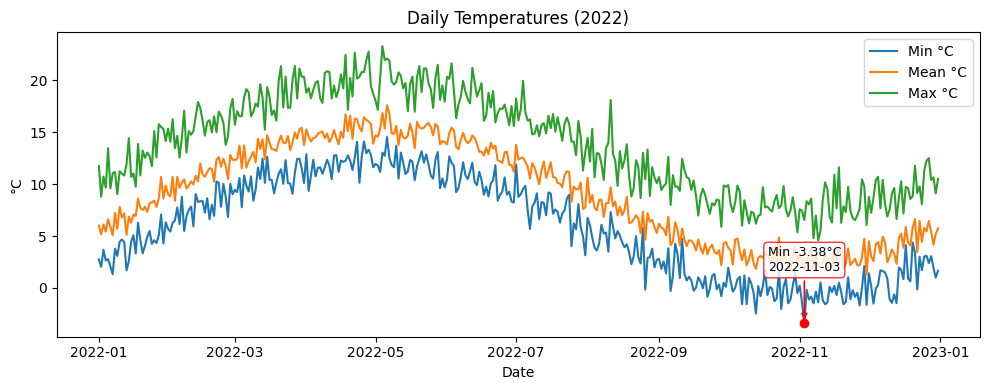

In [15]:
plt.figure(figsize=(10,4))
plt.plot(df_2022["measurement_date"], df_2022["min_c"],  label="Min °C")
plt.plot(df_2022["measurement_date"], df_2022["mean_c"], label="Mean °C")
plt.plot(df_2022["measurement_date"], df_2022["max_c"],  label="Max °C")

# Find and label the minimum temperature point
idx_min = df_2022["min_c"].idxmin()
min_day = df_2022.loc[idx_min, "measurement_date"]
min_val = df_2022.loc[idx_min, "min_c"]

plt.scatter(min_day, min_val, color="red", zorder=5)
plt.annotate(
    f"Min {min_val:.2f}°C\n{min_day.date()}",
    xy=(min_day, min_val),
    xytext=(min_day, min_val + 5),  # move label further away
    arrowprops=dict(arrowstyle="->", color="red", lw=1.2),
    ha="center",
    fontsize=9,
    color="black",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="red", alpha=0.8)
)

plt.title("Daily Temperatures (2022)")
plt.xlabel("Date")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.show()

## Demo Environment

In [16]:
session = SQLiteSession("ConversationID")

In [17]:
async def ask_loop():
    while True:
        try:
            question = input("\nAsk a question (or type 'exit' to quit): ").strip()
        except (EOFError, KeyboardInterrupt):
            print("Exiting.")
            break

        if question.lower() in {"exit", "quit"}:
            print("Exiting.")
            break

        result = Runner.run(sql_agent, question, session=session)
        if hasattr(result, "__await__"):
            result = await result

        print("\n--- Agent Response ---")
        print(getattr(result, "final_output", result))

In [18]:
await ask_loop()


Ask a question (or type 'exit' to quit):  What was the minimum temperature recorded in 2022?



--- Agent Response ---
The minimum temperature recorded in 2022 was -3.38°C.



Ask a question (or type 'exit' to quit):  Which date was this?



--- Agent Response ---
The minimum temperature of -3.38°C was recorded on November 3, 2022.



Ask a question (or type 'exit' to quit):  exit


Exiting.
